In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definición de la matriz base (Imagen simplificada 5x5)
imagen = np.array([
    [10, 10, 10, 0, 0],
    [10, 10, 10, 0, 0],
    [10, 10, 10, 0, 0],
    [10, 10, 10, 0, 0],
    [10, 10, 10, 0, 0]
])

# 2. Definición del Kernel (Filtro de detección de bordes verticales)
kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

print("Imagen Original (5x5):\n", imagen)
print("\nKernel (3x3):\n", kernel)

Imagen Original (5x5):
 [[10 10 10  0  0]
 [10 10 10  0  0]
 [10 10 10  0  0]
 [10 10 10  0  0]
 [10 10 10  0  0]]

Kernel (3x3):
 [[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]


Celda 2: Función de Convolución Manual

In [2]:
def convolucion_manual(matriz, kernel, padding=0, stride=1):
    # Aplicar Padding (Relleno de ceros)
    if padding > 0:
        matriz = np.pad(matriz, pad_width=padding, mode='constant', constant_values=0)

    m_h, m_w = matriz.shape
    k_h, k_w = kernel.shape

    # Calcular dimensiones de salida
    out_h = (m_h - k_h) // stride + 1
    out_w = (m_w - k_w) // stride + 1

    salida = np.zeros((out_h, out_w))

    # Operación de convolución
    for i in range(0, out_h):
        for j in range(0, out_w):
            region = matriz[i*stride:i*stride+k_h, j*stride:j*stride+k_w]
            salida[i, j] = np.sum(region * kernel)

    return salida

Celda 3: Experimentos (Padding vs Stride)

In [3]:
# Caso A: Convolución Simple (Sin padding, Stride 1)
resultado_simple = convolucion_manual(imagen, kernel, padding=0, stride=1)

# Caso B: Convolución con Padding (Mantiene mejor la dimensión)
resultado_padding = convolucion_manual(imagen, kernel, padding=1, stride=1)

# Caso C: Convolución con Stride 2 (Reduce drásticamente el tamaño)
resultado_stride = convolucion_manual(imagen, kernel, padding=0, stride=2)

print("Tamaño Simple:", resultado_simple.shape)
print("Tamaño con Padding 1:", resultado_padding.shape)
print("Tamaño con Stride 2:", resultado_stride.shape)

Tamaño Simple: (3, 3)
Tamaño con Padding 1: (5, 5)
Tamaño con Stride 2: (2, 2)


Celda 4: Visualización y Conclusiones

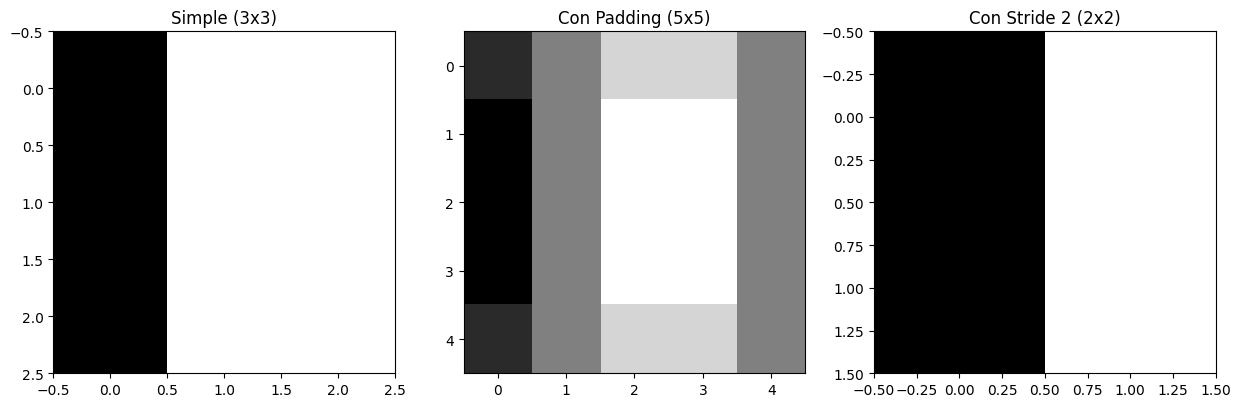

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(resultado_simple, cmap='gray'); ax[0].set_title("Simple (3x3)")
ax[1].imshow(resultado_padding, cmap='gray'); ax[1].set_title("Con Padding (5x5)")
ax[2].imshow(resultado_stride, cmap='gray'); ax[2].set_title("Con Stride 2 (2x2)")
plt.show()

